In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Functions.Utils import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as rmse
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

path = r'Datasets\DEVRT\NISSAN LEAF\20230420_NISSAN_DONOSTIA_HERNANI_046.csv'
df = pd.read_csv(path)
df.fillna(0, inplace=True)
df.head()


pwr = (df['Motor Pwr(w)'].values)
spd = (df['speed'].values)
rpm = (df['rpm'].values)
trq = (df['Torque Nm'].values)
elv = (df['elv_spy'].values)
lat = (df['latitude'].values)
lon = (df['longitude'].values)
alt = (df['altitude'].values)
df1 = pd.DataFrame({'speed': spd, 'rpm': rpm, 'torque': trq, 'elv': elv,'lat': lat, 'lon': lon, 'alt': alt, 'power': pwr,})
#df2 = exponential_moving_average_df(df1,0.5)
df2 = moving_average_df(df1,3)
#df = pd.DataFrame({'speed': spd, 'rpm': rpm, 'torque': trq, 'elv': elv, 'power': pwr,})
#df = pd.DataFrame({'speed': spd, 'rpm': rpm, 'torque': trq, 'power': pwr,})


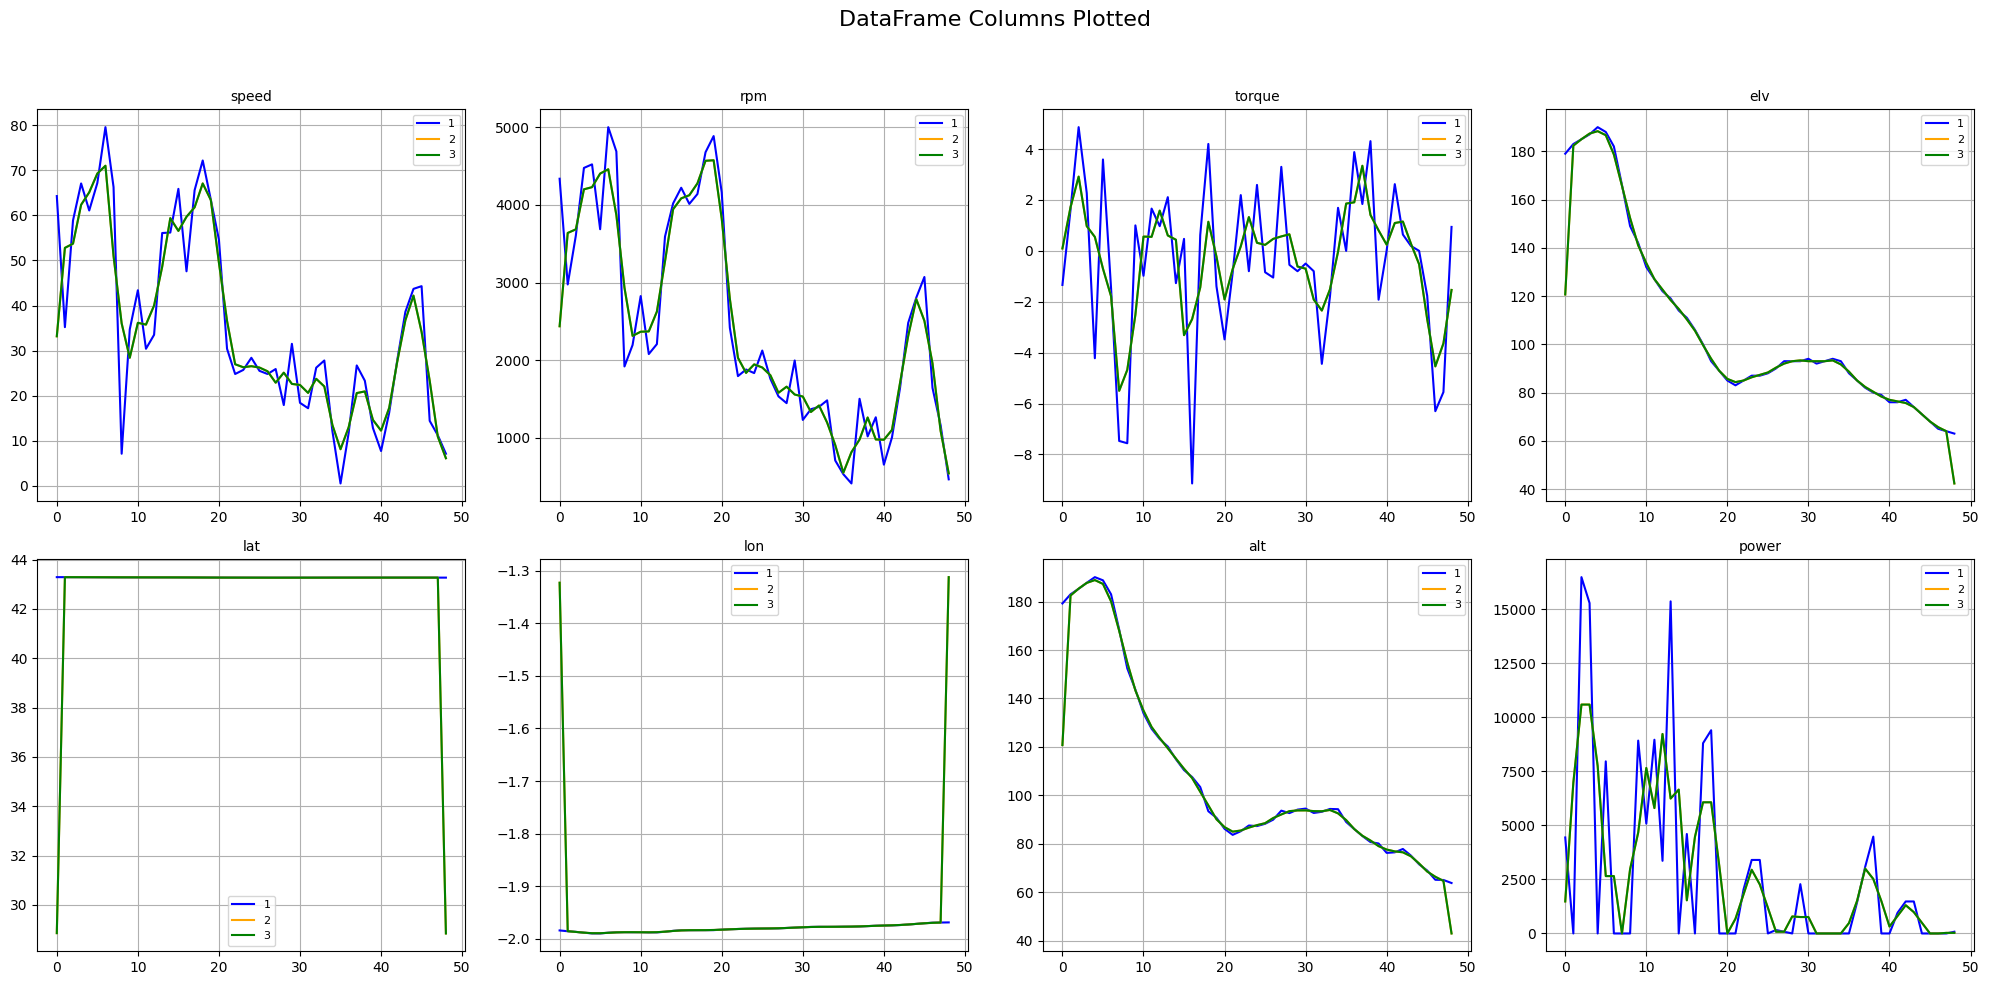

In [6]:
plot_dataframe2(df1,df2,df2)

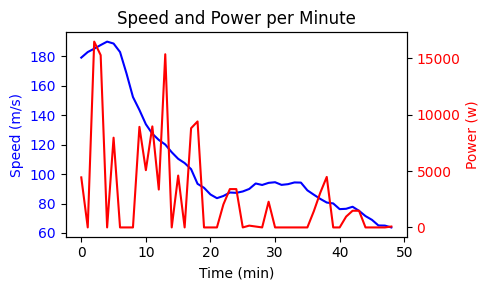

In [7]:
out='Images/DEVRT_dataset.png'
PlotTwoScales(y1=alt[:],y2=pwr[:],y1_name='Speed (m/s)', y2_name='Power (w)',x_name='Time (min)',out=out,title='Speed and Power per Minute')

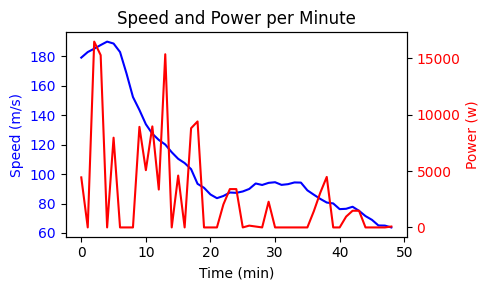

In [8]:
out='Images/DEVRT_dataset.png'
PlotTwoScales(y1=alt[:],y2=pwr[:],y1_name='Speed (m/s)', y2_name='Power (w)',x_name='Time (min)',out=out,title='Speed and Power per Minute')

In [19]:
df.columns

Index(['timestamp_data_utc', 'elv_spy', 'speed', 'soc', 'amb_temp', 'soh',
       'regenwh', 'Motor Pwr(w)', 'Aux Pwr(100w)', 'Motor Temp', 'Torque Nm',
       'rpm', 'route_id', 'longitude', 'latitude', 'altitude', 'cumul_dist',
       'timestamp_gps_utc', 'car_id', 'time_diff', 'point_geom', 'route_code',
       'route_description', 'driver', 'start_timestamp', 'end_timestamp',
       'car_code', 'car_description', 'capacity', 'ref_consumption',
       'timestamp_weather_utc', 'wind_mph', 'wind_kph', 'wind_degree',
       'wind_dir', 'Frontal_Wind', 'Veh_deg', 'totalVehicles', 'speedAvg',
       'cars_by_speed_interval_0_80', 'cars_by_speed_interval_80_100',
       'cars_by_speed_interval_100_120', 'cars_by_speed_interval_0_50',
       'cars_by_speed_interval_50_80', 'cars_by_speed_interval_80_120',
       'cars_by_speed_interval_120_inf', 'cars_by_length_interval_0_7',
       'cars_by_length_interval_7_inf', 'max_speed', 'radius'],
      dtype='object')

In [ ]:
# 1. Configuração do dispositivo (Usa sua RTX 4060 se o CUDA estiver ativo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando no dispositivo: {device}")


# Para o treino funcionar bem, vamos inflar esses dados repetindo-os (simulando uma série longa)
df = pd.concat([df] * 1, ignore_index=True)

#df['power'] += np.random.normal(0, 50, size=len(df)) # adiciona um ruído para o treino

# Separando Inputs (X) e Output (y)
X_raw = df[['speed', 'rpm', 'Torque Nm']].values
y_raw = df['Motor Pwr(w)'].values.reshape(-1, 1)

# --- 3. Pré-processamento e Normalização ---
# LSTMs são muito sensíveis à escala dos dados (especialmente com RPM na casa dos 20k e torque negativo)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# Função para criar janelas temporais (Sequências deslizantes)
def criar_sequencias(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Vamos usar as últimas 3 linhas (passos de tempo) para prever a próxima potência
LOOKBACK = 3 
X_seq, y_seq = criar_sequencias(X_scaled, y_scaled, time_steps=LOOKBACK)

# Conversão para tensores do PyTorch
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.float32)

# Criação do DataLoader para gerenciar os lotes (Batches) de treino
dataset = TensorDataset(X_tensor, y_tensor)

# Aumentamos o batch_size para 256 e ativamos shuffle e pin_memory para a GPU
dataloader = DataLoader(
    dataset, 
    batch_size=256, 
    shuffle=True, 
    pin_memory=True if torch.cuda.is_available() else False
)

Rodando no dispositivo: cuda


In [21]:
# --- 4. Construção da Arquitetura LSTM ---
class PowerPredictorLSTM(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32, num_layers=2, output_dim=1):
        super(PowerPredictorLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Camada LSTM
        # batch_first=True indica que a entrada possui o formato: [Batch, Time_Steps, Features]
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # Camada de saída Totalmente Conectada (Linear)
        self.linear = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # Inicialização dos estados ocultos (h0) e de célula (c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Saída da LSTM: out terá o formato [Batch, Time_Steps, Hidden_Dim]
        out, _ = self.lstm(x, (h0, c0))
        
        # Pegamos apenas o último passo de tempo da sequência para passar para a camada linear
        out = self.linear(out[:, -1, :])
        return out

# Inicializa o lstmo
lstm = PowerPredictorLSTM(input_dim=3, hidden_dim=32, num_layers=2, output_dim=1).to(device)

# --- 5. Critério de Erro e Otimizador ---
criterion = nn.MSELoss() # Erro Quadrático Médio, ideal para regressão de potência
optimizer = torch.optim.Adam(lstm.parameters(), lr=0.005)

# --- 6. Loop de Treinamento de Alta Performance (Substitua a seção 6) ---
lstm.train()
print(f"\nIniciando o treinamento da LSTM na {device}...")

# Criamos um gerador de escala para usar FP16 (Precisão Mista) se estiver na GPU
# Isso dobra a velocidade de cálculo na arquitetura Ada Lovelace da RTX 4060
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

for epoch in range(10):
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        # non_blocking=True acelera a cópia assíncrona para a GPU
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        
        # Limpa os gradientes
        optimizer.zero_grad(set_to_none=True) # set_to_none poupa memória de cache
        
        # Forward pass com autocast (FP16/FP32 mistos)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            predictions = lstm(batch_X)
            loss = criterion(predictions, batch_y)
        
        # Backward pass otimizado pelo Scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item() * batch_X.size(0)
        
    total_loss = epoch_loss / len(dataloader.dataset)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/40] | Erro MSE: {total_loss:.6f}")

# --- 7. Teste de Predição com Inversão de Escala ---
lstm.eval()
with torch.no_grad():
    # Pegamos a primeira janela de teste do próprio dataset para validar
    exemplo_entrada = X_tensor[0:1].to(device) 
    predicao_normalizada = lstm(exemplo_entrada).cpu().numpy()
    
    # Desnormaliza o resultado para voltar a unidade real de Potência (Watts ou kW)
    predicao_real = scaler_y.inverse_transform(predicao_normalizada)
    valor_real = scaler_y.inverse_transform(y_tensor[0:1].numpy())
    
    print("-" * 50)
    print(f"Potência Real Esperada: {valor_real[0][0]:.2f}")
    print(f"Potência Predita pela LSTM: {predicao_real[0][0]:.2f}")


Iniciando o treinamento da LSTM na cuda...


C:\Users\Claudio\AppData\Local\Temp\ipykernel_800\3627626018.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
C:\Users\Claudio\AppData\Local\Temp\ipykernel_800\3627626018.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Época [1/40] | Erro MSE: 0.094467
Época [5/40] | Erro MSE: 0.057570
Época [10/40] | Erro MSE: 0.056251
--------------------------------------------------
Potência Real Esperada: 15280.00
Potência Predita pela LSTM: 2531.50


In [22]:
# --- 1. Criar listas vazias para acumular as predições ---
y_reais_lista = []
y_preditos_lista = []

# Altera o lstmo para o modo de avaliação (inferência)
lstm.eval()

# Desliga o cálculo de gradientes para economizar memória VRAM da GPU
with torch.no_grad():
    for batch_X, batch_y in dataloader:
        # Envia os dados do lote para a GPU (RTX 4060)
        batch_X = batch_X.to(device)
        
        # Realiza a predição (Forward Pass)
        predictions = lstm(batch_X)
        
        # Move os resultados de volta para a CPU e converte para arrays do NumPy
        # .cpu().numpy() é obrigatório para salvar dados fora da VRAM
        y_reais_lista.append(batch_y.numpy())
        y_preditos_lista.append(predictions.cpu().numpy())

# --- 2. Concatenar os lotes em um único vetor contínuo ---
y_reais_comprimidos = np.vstack(y_reais_lista)
y_preditos_comprimidos = np.vstack(y_preditos_lista)

# --- 3. Desnormalizar os vetores para voltar à unidade real (Watts/kW) ---
y_real = scaler_y.inverse_transform(y_reais_comprimidos).flatten()
y_pred = scaler_y.inverse_transform(y_preditos_comprimidos).flatten()

# Agora você tem os dois vetores limpos e prontos:
# y_real -> Vetor NumPy com os valores reais do dataset
# y_pred -> Vetor NumPy com os valores preditos pela LSTM

print("Estrutura dos vetores gerados:")
print(f"Shape y_real: {y_real.shape} | Shape y_pred: {y_pred.shape}\n")

Estrutura dos vetores gerados:
Shape y_real: (46,) | Shape y_pred: (46,)



In [24]:
# 1. Configuração do dispositivo (Usa sua RTX 4060 se o CUDA estiver ativo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando no dispositivo: {device}")

# Para o treino funcionar bem, vamos inflar esses dados repetindo-os (simulando uma série longa)
df = pd.concat([df] * 20, ignore_index=True)
#df['power'] += np.random.normal(0, 50, size=len(df)) # adiciona um ruído para o treino

# Separando Inputs (X) e Output (y)
X_raw = df[['speed', 'rpm', 'Torque Nm']].values
y_raw = df['Motor Pwr(w)'].values.reshape(-1, 1)

# --- 3. Pré-processamento e Normalização ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# --- MODIFICAÇÃO 1: FUNÇÃO DE SEQUÊNCIAS MULTI-PASSO ---
def criar_sequencias_multi_passo(X, y, time_steps=3, steps_ahead=4):
    Xs, ys = [], []
    # O limite do loop precisa considerar o horizonte de predição à frente
    for i in range(len(X) - time_steps - steps_ahead + 1):
        Xs.append(X[i:(i + time_steps)])
        # Coleta os alvos dos instantes: k, k+1, k+2 e k+3
        ys.append(y[(i + time_steps):(i + time_steps + steps_ahead)].flatten())
    return np.array(Xs), np.array(ys)

LOOKBACK = 3 
STEPS_AHEAD = 4 # k, k+1, k+2, k+3

X_seq, y_seq = criar_sequencias_multi_passo(X_scaled, y_scaled, time_steps=LOOKBACK, steps_ahead=STEPS_AHEAD)

# Conversão para tensores do PyTorch
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.float32) # Shape agora será [N, 4]

# Criação do DataLoader para gerenciar os lotes (Batches) de treino
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(
    dataset, 
    batch_size=256, 
    shuffle=True, 
    pin_memory=True if torch.cuda.is_available() else False
)

# --- MODIFICAÇÃO 2: ARQUITETURA CONFIGURADA PARA OUTPUT_DIM = 4 ---
class PowerPredictorLSTM(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32, num_layers=2, output_dim=4):
        super(PowerPredictorLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Camada LSTM
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # A camada linear agora mapeia as features ocultas para as 4 predições futuras
        self.linear = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        
        # Passa o último estado oculto da sequência para a saída de 4 dimensões
        out = self.linear(out[:, -1, :])
        return out

# Inicializa o lstmo com output_dim=4
lstm = PowerPredictorLSTM(input_dim=3, hidden_dim=32, num_layers=2, output_dim=STEPS_AHEAD).to(device)

# --- 5. Critério de Erro e Otimizador ---
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(lstm.parameters(), lr=0.005)

# --- 6. Loop de Treinamento de Alta Performance ---
lstm.train()
print(f"\nIniciando o treinamento da LSTM Multi-Passo na {device}...")

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

for epoch in range(20):
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            predictions = lstm(batch_X)
            loss = criterion(predictions, batch_y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item() * batch_X.size(0)
        
    total_loss = epoch_loss / len(dataloader.dataset)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/20] | Erro MSE Geral: {total_loss:.6f}")

# --- 7. Teste de Predição e Desnormalização Vetorial ---
lstm.eval()
with torch.no_grad():
    # Pega uma amostra de teste para conferência
    exemplo_entrada = X_tensor[0:1].to(device) 
    predicao_normalizada = lstm(exemplo_entrada).cpu().numpy()
    
    # Como scaler_y foi treinado com formato (N, 1), precisamos redimensionar 
    # temporariamente para desnormalizar os 4 passos corretamente
    predicao_real = scaler_y.inverse_transform(predicao_normalizada.reshape(-1, 1)).flatten()
    valor_real = scaler_y.inverse_transform(y_tensor[0:1].numpy().reshape(-1, 1)).flatten()
    
    print("-" * 50)
    print("Janela Futura Esperada (Real):", [round(v, 2) for v in valor_real])
    print("Janela Futura Predita (LSTM): ", [round(v, 2) for v in predicao_real])

Rodando no dispositivo: cuda

Iniciando o treinamento da LSTM Multi-Passo na cuda...


C:\Users\Claudio\AppData\Local\Temp\ipykernel_800\596216225.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
C:\Users\Claudio\AppData\Local\Temp\ipykernel_800\596216225.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Época [1/20] | Erro MSE Geral: 0.062659
Época [5/20] | Erro MSE Geral: 0.001220
Época [10/20] | Erro MSE Geral: 0.000171
Época [15/20] | Erro MSE Geral: 0.000064
Época [20/20] | Erro MSE Geral: 0.000087
--------------------------------------------------
Janela Futura Esperada (Real): [15280.0, 0.0, 7960.0, 0.0]
Janela Futura Predita (LSTM):  [14798.89, 41.09, 7957.36, 105.61]


In [25]:
# --- 1. Rodar Inferência em Lotes Ordenados para Evitar Estouro de VRAM ---
lstm.eval() # Ativa modo de avaliação

predicoes_lista = []
BATCH_PRED = 512 # Tamanho do bloco de leitura para a GPU

# Usamos um laço para fatiar o tensor cronologicamente
with torch.no_grad():
    for i in range(0, len(X_tensor), BATCH_PRED):
        # Recorta um lote de dados contínuos da memória RAM
        lote_x = X_tensor[i:i + BATCH_PRED].to(device)
        
        # Executa o lstmo para o lote atual
        pred_lote = lstm(lote_x)
        
        # Traz apenas o resultado processado para a CPU e limpa a VRAM
        predicoes_lista.append(pred_lote.cpu().numpy())

# Junta todos os lotes de predição em uma única matriz contínua [N, 4]
predicoes_normalizadas = np.vstack(predicoes_lista)

# --- 2. Desnormalização dos Blocos Vetoriais (Continuação do seu script) ---
y_real_normalizado = y_tensor.numpy()

# Transposição para desnormalizar cada horizonte individualmente
y_real_unidade = scaler_y.inverse_transform(y_real_normalizado.T).T
y_pred_unidade = scaler_y.inverse_transform(predicoes_normalizadas.T).T

# --- 3. Armazenar os Resultados em Vetores Separados ---
y_real_k   = y_real_unidade[:, 0]
y_real_k1  = y_real_unidade[:, 1]
y_real_k2  = y_real_unidade[:, 2]
y_real_k3  = y_real_unidade[:, 3]

y_pred_k   = y_pred_unidade[:, 0]
y_pred_k1  = y_pred_unidade[:, 1]
y_pred_k2  = y_pred_unidade[:, 2]
y_pred_k3  = y_pred_unidade[:, 3]

print("Vetores gerados com absoluto sucesso e sem estourar a GPU!")
print(f"Quantidade total de pontos calculados cronologicamente: {len(y_real_k)}")

Vetores gerados com absoluto sucesso e sem estourar a GPU!
Quantidade total de pontos calculados cronologicamente: 19594


In [53]:
def PlotSeriesPLY2(xSeries=None,ySeries=None, names=None, title='Séries Temporais',
                  markers=None, xLabel=None, yLabel=None, w=600, h=400):
    
    if xSeries==None: 
        xSeries = [[i for i in range(len(ySeries[j]))] for j in range(len(ySeries))]
    
    if xLabel is None: xLabel = 'X'
    if yLabel is None: yLabel = 'Y'
    #lines = ['None',dict(dash='dash')]
    lines = ['solid','dash']
    x=xSeries
    y=ySeries
    line_modes = ['lines', 'markers']
    fig = make_subplots(rows=1, cols=1)
    
    if names is None:
        names = [f'Série {i+1}' for i in range(len(y))]
    if markers is None:
        markers = [0] * len(y) # Padrão para todos como 'lines'

    for x, y, name, m_idx, Line in zip(x, y, names, markers, lines):
        mode = line_modes[m_idx] if m_idx < len(line_modes) else 'lines'
        fig.add_trace(go.Scatter(x=x, y=y, name=name, mode=mode,line=dict(dash=Line)),row=1, col=1)

    fig.update_layout(width=w, height=h, title=title,template='plotly_white')
    fig.update_yaxes(title_text=yLabel, row=1, col=1,)
    fig.update_xaxes(title_text=xLabel, row=1, col=1,)
    fig.show()

In [54]:
PlotSeriesPLY2(ySeries=[y_real_k[:300],y_pred_k[:300]], xLabel='5 Step Ahead Prediction', yLabel='Demand Power', title='Power Demand Prediction', names=['Real', 'Prediction'])

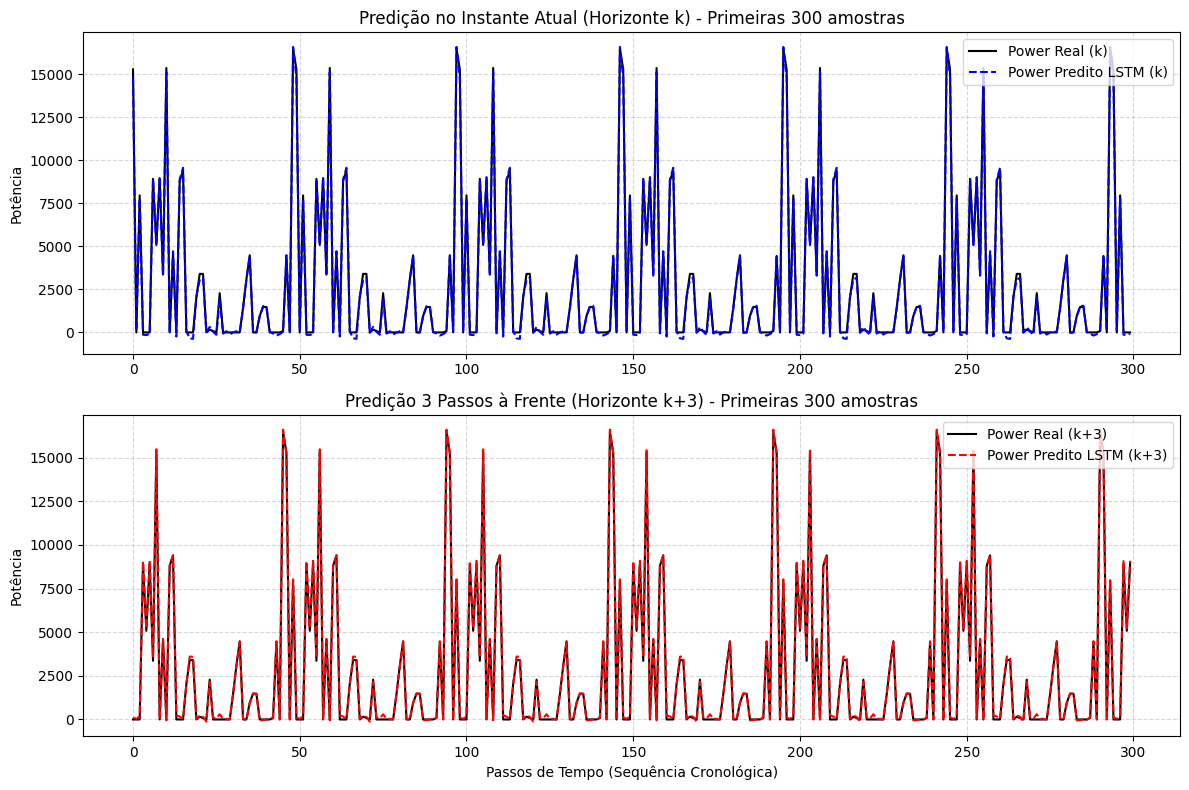

In [26]:
# Criando a figura para comparação dos horizontes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Subplot 1: Predição no Instante Atual (k) - Geralmente mais precisa
ax1.plot(y_real_k[:300], label='Power Real (k)', color='black', linewidth=1.5)
ax1.plot(y_pred_k[:300], label='Power Predito LSTM (k)', color='blue', linestyle='--', linewidth=1.5)
ax1.set_title('Predição no Instante Atual (Horizonte k) - Primeiras 300 amostras')
ax1.set_ylabel('Potência')
ax1.legend(frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Predição 3 Passos à Frente (k+3) - Onde o erro tende a acumular
ax1.set_xlabel('') # Remove o label superior
ax2.plot(y_real_k3[:300], label='Power Real (k+3)', color='black', linewidth=1.5)
ax2.plot(y_pred_k3[:300], label='Power Predito LSTM (k+3)', color='red', linestyle='--', linewidth=1.5)
ax2.set_title('Predição 3 Passos à Frente (Horizonte k+3) - Primeiras 300 amostras')
ax2.set_xlabel('Passos de Tempo (Sequência Cronológica)')
ax2.set_ylabel('Potência')
ax2.legend(frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()